In [1]:
!pip install tensorflow opencv-python scikit-learn -q
import tensorflow as tf
print(tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [1]:
!pip install kaggle -q
from google.colab import files
files.upload()  # upload your kaggle.json here

Output hidden; open in https://colab.research.google.com to view.

In [2]:
import pandas as pd

df = pd.read_csv('hmnist_28_28_RGB.csv')
print(df.shape)
print(df['label'].value_counts())
df.head()

(10015, 2353)
label
4    6705
6    1113
2    1099
1     514
0     327
5     142
3     115
Name: count, dtype: int64


,pixel0000,pixel0001,pixel0002,pixel0003,pixel0004,pixel0005,pixel0006,pixel0007,pixel0008,pixel0009,...,pixel2343,pixel2344,pixel2345,pixel2346,pixel2347,pixel2348,pixel2349,pixel2350,pixel2351,label
0,192,153,193,195,155,192,197,154,185,202,...,173,124,138,183,147,166,185,154,177,2
1,25,14,30,68,48,75,123,93,126,158,...,60,39,55,25,14,28,25,14,27,2
2,192,138,153,200,145,163,201,142,160,206,...,167,129,143,159,124,142,136,104,117,2
3,38,19,30,95,59,72,143,103,119,171,...,44,26,36,25,12,17,25,12,15,2
4,158,113,139,194,144,174,215,162,191,225,...,209,166,185,172,135,149,109,78,92,2


In [3]:
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

# Separate features and labels
X = df.drop('label', axis=1).values
y = df['label'].values

# Reshape pixels into image format (28x28x3)
X = X.reshape(-1, 28, 28, 3)

# Normalize pixel values (0-255 → 0-1)
X = X / 255.0

# One-hot encode labels
y_cat = to_categorical(y, num_classes=7)

# Train/test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_cat, test_size=0.2, random_state=42, stratify=y
)

print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (8012, 28, 28, 3) Test: (2003, 28, 28, 3)


In [4]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(28,28,3)),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(7, activation='softmax')  # 7 classes
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 26, 26, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 11, 11, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 3, 3, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 3, 3, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 242,631 (947.78 KB)

 Trainable params: 242,183 (946.03 KB)

 Non-trainable params: 448 (1.75 KB)

In [5]:
from sklearn.utils.class_weight import compute_class_weight

# Compute class weights
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y),
    y=y
)
class_weights_dict = dict(enumerate(class_weights))
print(class_weights_dict)

# Train the model
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=15,
    batch_size=32,
    class_weight=class_weights_dict
)

{0: np.float64(4.375273044997815), 1: np.float64(2.78349082823791), 2: np.float64(1.301832835044846), 3: np.float64(12.440993788819876), 4: np.float64(0.21338020666879728), 5: np.float64(10.075452716297788), 6: np.float64(1.2854575792581184)}
Epoch 1/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 17s 23ms/step - accuracy: 0.3883 - loss: 2.0058 - val_accuracy: 0.1083 - val_loss: 2.4204
Epoch 2/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4562 - loss: 1.6057 - val_accuracy: 0.2336 - val_loss: 2.0653
Epoch 3/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4827 - loss: 1.4390 - val_accuracy: 0.1912 - val_loss: 1.9807
Epoch 4/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.4611 - loss: 1.4068 - val_accuracy: 0.4488 - val_loss: 1.5333
Epoch 5/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.5051 - loss: 1.3214 - val_accuracy: 0.4703 - val_loss: 2.5449
Epoch 6/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.5341 - loss: 1.2365 - val_accuracy: 0.5467 - val_

63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

           0       0.00      0.00      0.00        65
           1       0.00      0.00      0.00       103
           2       0.00      0.00      0.00       220
           3       0.00      0.00      0.00        23
           4       0.00      0.00      0.00      1341
           5       0.01      1.00      0.03        28
           6       0.29      0.02      0.03       223

    accuracy                           0.02      2003
   macro avg       0.04      0.15      0.01      2003
weighted avg       0.03      0.02      0.00      2003



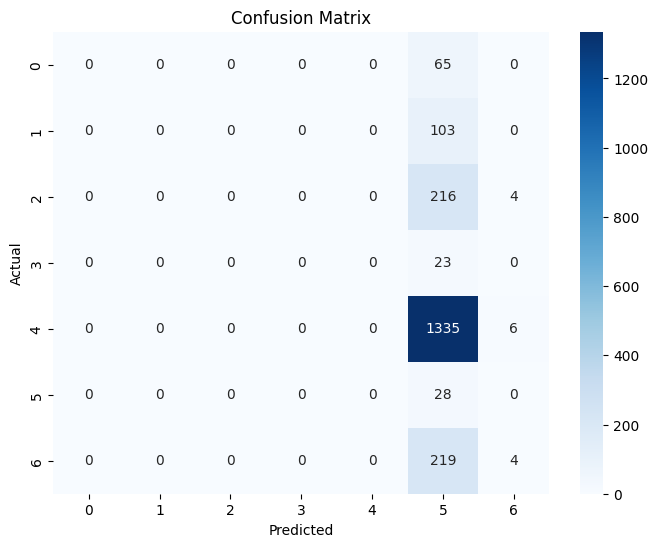

In [6]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Predictions
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

# Classification report
print(classification_report(y_true, y_pred_classes))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [7]:
# Save the trained model
model.save('/content/drive/MyDrive/SkinSense/skinsense_model.h5')
print("Model saved!")

# Label mapping (HAM10000 classes)
label_map = {
    0: 'akiec - Actinic keratoses',
    1: 'bcc - Basal cell carcinoma',
    2: 'bkl - Benign keratosis',
    3: 'df - Dermatofibroma',
    4: 'mel - Melanoma',
    5: 'nv - Melanocytic nevi',
    6: 'vasc - Vascular lesions'
}

# Prediction function
def predict_skin_condition(img_array):
    img_array = img_array.reshape(1, 28, 28, 3) / 255.0
    pred = model.predict(img_array)
    class_idx = np.argmax(pred)
    confidence = np.max(pred) * 100
    return label_map[class_idx], confidence

# Test on one sample from test set
sample_img = X_test[0] * 255  # de-normalize for testing
result, conf = predict_skin_condition(sample_img)
print

Model saved!
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 860ms/step


<function print(*args, sep=' ', end='\n', file=None, flush=False)>

In [8]:
!pip install gradio -q
import gradio as gr
from PIL import Image

def predict_from_image(img):
    img = img.resize((28, 28))
    img_array = np.array(img)
    if img_array.shape[-1] == 4:  # remove alpha channel if present
        img_array = img_array[:, :, :3]
    result, conf = predict_skin_condition(img_array)
    return f"{result} ({conf:.2f}% confidence)"

demo = gr.Interface(
    fn=predict_from_image,
    inputs=gr.Image(type="pil"),
    outputs="text",
    title="SkinSense - Skin Disease Detector",
    description="Upload a skin lesion image to get a prediction"
)

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://e47ee9f0fd403a8e22.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [9]:
# In Colab, first save your notebook code as a .py file or just keep .ipynb
# Then set up git (run in a cell with ! prefix)

!git config --global user.email "your-email@example.com"
!git config --global user.name "ashwinivindravath1729-beep"